<div style="background:linear-gradient(135deg,#3b1d6e 0%,#6d28d9 55%,#a855f7 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#e6dbff;font-weight:700;text-transform:uppercase">Chapter 29 · Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Palmer Penguins 🐧</div>
  <div style="font-size:15px;color:#efe7ff;max-width:720px;line-height:1.6">A small, friendly file of 347 Antarctic penguins, and the perfect closer for Part V. We audit, visualize, clean, and encode, and meet a famous statistical trap along the way.</div>
  <div style="margin-top:16px;font-size:13px;color:#e6dbff">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; load
Loads from the book's `data/` folder (local) with a GitHub raw-URL fallback (Colab).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
CYAN="#0891b2"; AMBER="#d97706"; PURPLE="#7c3aed"; GREEN="#059669"; PINK="#db2777"; INK="#1a2138"; GRID="#e6e9f2"
SPC = {"Adelie":CYAN, "Chinstrap":AMBER, "Gentoo":PURPLE}
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})

BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/penguins.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"penguins.csv")
raw_rows = len(df)
print("loaded:", df.shape)

loaded: (347, 10)


<div style="background:#f3edff;border-left:5px solid #7c3aed;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#7c3aed;letter-spacing:1px">BEAT 1 · FIRST CONTACT</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">A small, almost-tidy file</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">The friendliest dataset of the three. Most rows are clean, so the audit is about spotting the <i>few</i> problems: a couple of empty rows, a messy <code>sex</code> column, and one impossible measurement.</div>
</div>

In [2]:
meas = ["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]
print("shape:", df.shape, "| duplicate rows:", int(df.duplicated().sum()))
print("\nmissing:\n", df.isna().sum()[df.isna().sum()>0].to_string())
print("\nsex typed many ways:", df["sex"].value_counts(dropna=False).to_dict())
print("\nflipper_length_mm range:", df["flipper_length_mm"].min(), "to", df["flipper_length_mm"].max(),
      "<- 19.5 is impossible (cm not mm)")
df.head(3)

shape: (347, 10) | duplicate rows: 3

missing:
 bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
sex                  7
body_size            2

sex typed many ways: {'male': 174, 'female': 155, nan: 7, '.': 4, 'MALE': 4, 'Female ': 3}

flipper_length_mm range: 19.5 to 237.0 <- 19.5 is impossible (cm not mm)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_size,band_color
0,Adelie,Biscoe,36.8,17.6,184.0,3381.0,female,2008,small,red
1,Adelie,Dream,39.2,17.5,182.0,3826.0,female,2009,Medium,GREEN
2,Gentoo,Biscoe,45.8,13.7,215.0,5594.0,female,2009,large,red


**The audit:** three duplicate rows; two rows missing *every* measurement; a `sex` column holding `male`, `female`, `MALE`, `Female `, `.`, and blanks; one `flipper_length_mm` of **19.5** (a penguin flipper is ~190 mm, so this is centimeters by mistake); plus two messy category columns, `body_size` and `band_color`. Short list, but each needs a different fix.

<div style="background:#f3edff;border-left:5px solid #7c3aed;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#0891b2;letter-spacing:1px">BEAT 2 · VISUALIZE</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Three species, and a famous trap</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">The classic penguin chart: bill length against bill depth, colored by species. It tells two stories at once, three clean clusters, and a correlation that <b>reverses</b> when you look closer.</div>
</div>

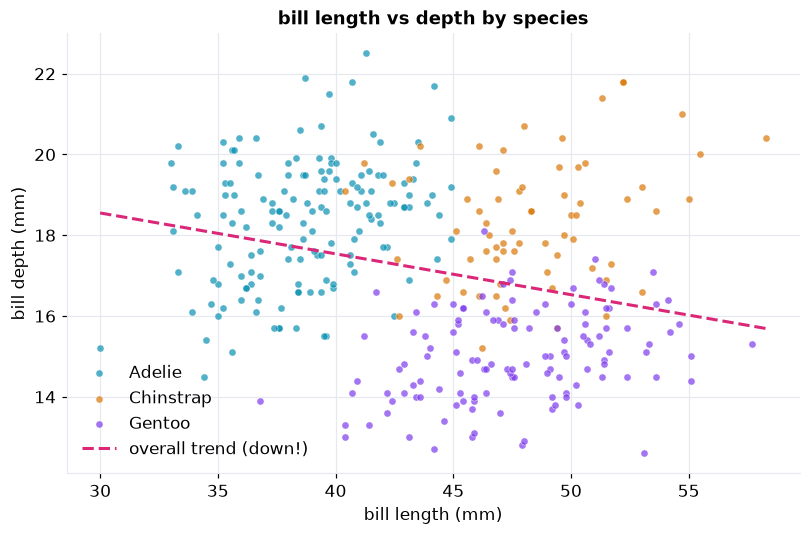

bill_length vs bill_depth correlation:
  OVERALL          : -0.27 (negative)
  within Adelie    : 0.28 (positive)
  within Chinstrap : 0.26 (positive)
  within Gentoo    : 0.3 (positive)


In [3]:
sub = df.dropna(subset=["bill_length_mm","bill_depth_mm"])
fig, ax = plt.subplots(figsize=(7.5,5))
for sp, c in SPC.items():
    s = sub[sub["species"]==sp]
    ax.scatter(s["bill_length_mm"], s["bill_depth_mm"], color=c, s=22, alpha=0.7, edgecolor="white", linewidth=0.4, label=sp)
# overall trend (ignoring species)
m,b = np.polyfit(sub["bill_length_mm"], sub["bill_depth_mm"], 1)
xs = np.array([sub["bill_length_mm"].min(), sub["bill_length_mm"].max()])
ax.plot(xs, m*xs+b, "--", color="#db2777", lw=2, label="overall trend (down!)")
ax.set_xlabel("bill length (mm)"); ax.set_ylabel("bill depth (mm)")
ax.set_title("bill length vs depth by species"); ax.legend()
plt.tight_layout(); plt.show()

print("bill_length vs bill_depth correlation:")
print("  OVERALL          :", round(sub["bill_length_mm"].corr(sub["bill_depth_mm"]),2), "(negative)")
for sp in SPC:
    s = sub[sub["species"]==sp]
    print(f"  within {sp:<10}:", round(s["bill_length_mm"].corr(s["bill_depth_mm"]),2), "(positive)")

**Simpson's paradox, live.** Overall, bill length and bill depth are *negatively* correlated (r ≈ −0.29): the dashed line slopes down. But **within every single species the correlation is positive** (r ≈ +0.2 to +0.3). The reversal happens because Gentoos (purple) have long, shallow bills and sit in their own corner, dragging the overall trend down. Lesson: a correlation computed across mixed groups can point the *opposite* way to the truth, which is why we color by species and always ask "compared to what?" (Chapters 15, 16, and the correlation-vs-causation idea ahead).

<div style="background:#f3edff;border-left:5px solid #7c3aed;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#059669;letter-spacing:1px">BEAT 3 · CLEAN</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Duplicates, a unit error, and empty rows</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Three quick structural fixes (Ch 19, 21). Drop the exact duplicates, correct the impossible flipper value, and remove the rows that carry no measurements at all.</div>
</div>

In [4]:
clean = df.drop_duplicates().copy()
print(f"deduplicate: {raw_rows} -> {len(clean)}  ({raw_rows-len(clean)} exact duplicates)")

# the unit-error outlier: 19.5 cm should be 195 mm -> multiply the sub-50 values by 10
bad = clean["flipper_length_mm"] < 50
print(f"unit-error flippers (<50mm): {int(bad.sum())}  ->", clean.loc[bad,"flipper_length_mm"].to_list())
clean.loc[bad, "flipper_length_mm"] *= 10
print("flipper range after fix:", clean["flipper_length_mm"].min(), "to", clean["flipper_length_mm"].max())

# rows with NO measurements at all carry no information -> drop
meas = ["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]
before = len(clean); clean = clean.dropna(subset=meas, how="all")
print(f"dropped {before-len(clean)} all-missing rows; {len(clean)} remain")

deduplicate: 347 -> 344  (3 exact duplicates)
unit-error flippers (<50mm): 1  -> [19.5]
flipper range after fix: 165.0 to 237.0
dropped 2 all-missing rows; 342 remain


**Why each:** duplicates would double-count birds (Ch 19). The 19.5 mm flipper is not an outlier to delete but a **unit error to correct**, it is centimeters, so multiplying by 10 restores the true ~195 mm (Ch 21). And a row missing every measurement cannot be imputed sensibly, so it is dropped (Ch 20). Notice the judgment: one extreme value was *fixed*, not removed, because we understood why it was wrong.

<div style="background:#f3edff;border-left:5px solid #7c3aed;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#d97706;letter-spacing:1px">BEAT 4 · MISSING &amp; MESSY CATEGORIES</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Clean the text, then fill the gaps</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">The <code>sex</code> column is both messy and incomplete; the two new category columns just need tidying. Standardize first (Ch 19), then impute the remaining gaps (Ch 20).</div>
</div>

In [5]:
# standardize sex: trim, lowercase, turn "." and blanks into real missing values
clean["sex"] = (clean["sex"].astype("string").str.strip().str.lower()
                .replace({".": pd.NA, "": pd.NA}))
print("sex after standardizing:", clean["sex"].value_counts(dropna=False).to_dict())

# impute the few remaining missing sexes with the most common sex WITHIN each species
n_missing = int(clean["sex"].isna().sum())
clean["sex"] = clean.groupby("species")["sex"].transform(lambda s: s.fillna(s.mode().iloc[0]))
print(f"imputed {n_missing} missing sexes (mode within species):", clean["sex"].value_counts().to_dict())

# tidy the two new category columns
clean["body_size"]  = clean["body_size"].astype("string").str.strip().str.lower().replace({"med":"medium"})
clean["band_color"] = clean["band_color"].astype("string").str.strip().str.lower()
print("body_size :", sorted(clean["body_size"].dropna().unique()))
print("band_color:", sorted(clean["band_color"].dropna().unique()))

sex after standardizing: {'male': 176, 'female': 157, <NA>: 9}
imputed 9 missing sexes (mode within species): {'male': 183, 'female': 159}
body_size : ['large', 'medium', 'small']
band_color: ['blue', 'green', 'red', 'yellow']


**Two ideas here.** Cleaning `sex` is pure standardizing: trim whitespace, lowercase, and map junk tokens (`"."`, blanks) to a true `NaN` (Ch 19). Then the handful of genuine gaps are **imputed with the most common sex within the same species** rather than overall, a smarter fill that respects the structure of the data (Ch 20). The `body_size` and `band_color` columns just need the same tidy-up before they can be encoded.

<div style="background:#f3edff;border-left:5px solid #7c3aed;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#7c3aed;letter-spacing:1px">BEAT 5 · ENCODE BY TYPE</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Ordinal vs one-hot, then a heatmap</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">The cleaned categories are encoded by <b>whether they have an order</b> (Ch 24). <code>body_size</code> is ordinal; <code>species</code>, <code>island</code>, <code>sex</code>, and <code>band_color</code> are nominal.</div>
</div>

ordinal body_size -> {'small': 1, 'medium': 2, 'large': 3}
one-hot columns: ['species_Adelie', 'species_Chinstrap', 'species_Gentoo', 'island_Biscoe', 'island_Dream', 'island_Torgersen', 'sex_female', 'sex_male', 'band_color_blue', 'band_color_green', 'band_color_red', 'band_color_yellow']


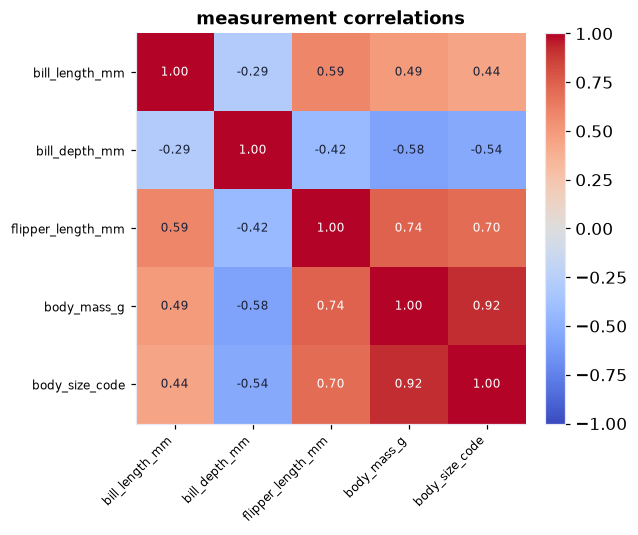

In [6]:
# ORDINAL: body_size small < medium < large -> 1, 2, 3 (order preserved)
clean["body_size_code"] = clean["body_size"].map({"small":1, "medium":2, "large":3})
# NOMINAL: one-hot the unordered categories
nominal = ["species","island","sex","band_color"]
onehot = pd.get_dummies(clean[nominal])
print("ordinal body_size ->", {"small":1,"medium":2,"large":3})
print("one-hot columns:", list(onehot.columns))

# correlation heatmap of the measurements + the ordinal code
feat = ["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g","body_size_code"]
corr = clean[feat].corr()
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(feat))); ax.set_xticklabels(feat, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(feat))); ax.set_yticklabels(feat, fontsize=8)
for i in range(len(feat)):
    for j in range(len(feat)):
        v=corr.iloc[i,j]
        ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=8,color="white" if abs(v)>0.6 else "#1a2138")
ax.set_title("measurement correlations"); ax.grid(False)
plt.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

**Reading the heatmap:** body mass and flipper length move together strongly (r ≈ 0.74), bigger penguins have bigger everything. The ordinal **body_size_code correlates 0.92 with body mass**, confirming the encoding faithfully captured the order (it was built to reflect size). And `bill_depth` is *negatively* related to mass and flipper (≈ −0.58), the same Gentoo effect behind Simpson's paradox: the biggest penguins (Gentoos) have the shallowest bills. Encoding `body_size` as 1/2/3 let an ordered category join this numeric analysis (Ch 24).

<div style="background:#f3edff;border-left:5px solid #7c3aed;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#0e6a8f;letter-spacing:1px">BEAT 6 · EXPLORE THE CLEAN DATA</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">What the clean data says</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Measurements by species, and a check on whether the arbitrary <code>band_color</code> tag carries any signal.</div>
</div>

In [7]:
print("mean measurements by species:")
print(clean.groupby("species")[meas].mean().round(1).to_string())

print("\nmean body mass by band_color (an arbitrary research tag):")
print(clean.groupby("band_color")["body_mass_g"].mean().round(0).to_string())
print("-> all ~4200g: the tag color is noise, exactly what a meaningless nominal looks like.")

# assemble the analysis-ready table
ready = pd.concat([clean[meas+["body_size_code"]].reset_index(drop=True),
                   onehot.reset_index(drop=True)], axis=1)
print("\nANALYSIS-READY:", ready.shape)
print(f"journey: {raw_rows} raw rows -> {len(ready)} clean rows, {ready.shape[1]} model-ready columns")

mean measurements by species:
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie               38.7           18.4              189.6       3679.7
Chinstrap            48.3           18.3              194.2       3737.5
Gentoo               47.6           15.0              217.7       5138.4

mean body mass by band_color (an arbitrary research tag):
band_color
blue      4224.0
green     4239.0
red       4206.0
yellow    4213.0
-> all ~4200g: the tag color is noise, exactly what a meaningless nominal looks like.

ANALYSIS-READY: (342, 17)
journey: 347 raw rows -> 342 clean rows, 17 model-ready columns


**The clean story:** the three species separate cleanly on size, Gentoos are the heavyweights (~5100 g) with long, shallow bills, while Adelies are the smallest. The `band_color` check is a deliberate negative result: mean mass is ~4200 g for every color, so the tag is **noise**. Confirming that a variable carries *no* signal is just as valuable as finding one that does, it stops you from chasing a phantom pattern.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎯 Recap: what we did and why</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:8px">
<li><b>Visualized first</b> and caught <b>Simpson's paradox</b>: bill length vs depth is negative overall but positive within each species.</li>
<li><b>Deduplicated</b> 3 rows, <b>corrected</b> a unit-error flipper (19.5 cm → 195 mm), and <b>dropped</b> 2 all-missing rows (Ch 19, 21, 20).</li>
<li><b>Standardized</b> the messy <code>sex</code> column and <b>imputed</b> the gaps with the mode within each species (Ch 19, 20).</li>
<li><b>Encoded by type</b>: <code>body_size</code> ordinal (1/2/3); <code>species</code>/<code>island</code>/<code>sex</code>/<code>band_color</code> one-hot (Ch 24).</li>
<li><b>Explored</b>: species separate by size; the ordinal code tracks mass (0.92); and band_color is confirmed <i>noise</i>.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>